<a href="https://colab.research.google.com/github/HTKhuongNinh-FPTU/MachineLearning-Doc/blob/main/PHAN_LOAI_RUOU_VAG_LOGISTICS_REGESTION_SE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bài toán: Dự đoán màu sắc của rượu (color: Red hoặc White) dựa trên các chỉ số hóa lý

## BƯỚC 1: EDA
kiểm tra cấu trúc, các đặc trưng (features) và phân phối của biến mục tiêu (target).

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [50]:
# 1. Đọc dữ liệu từ đường dẫn
df = pd.read_csv("/content/Wine_Quality_Data.csv")

# 2. Xem 5 dòng đầu tiên
print("Dữ liệu ban đầu:")
print(df.head())

# 3. Kiểm tra thông tin tổng quan
print("\nThông tin Dataset:")
df.info()

Dữ liệu ban đầu:
   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality color  
0      9.4        5   red  
1      9.8   

```KQ
Dữ liệu ban đầu:
   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality color  
0      9.4        5   red  
1      9.8        5   red  
2      9.8        5   red  
3      9.8        6   red  
4      9.4        5   red  

Thông tin Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
...
 12  color                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 688.6 KB
None
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
```


#### Mã hóa biến mục tiêu (Label Encoding)
Vì biến color đang ở dạng chuỗi (red, white), máy tính sẽ không hiểu được. Chúng ta cần chuyển nó về dạng số:
- Red $\rightarrow 1$
- White $\rightarrow 0$


In [51]:
# Mã hóa cột 'color' thành số (red = 1, white = 0)
df['color'] = df['color'].map({'red': 1, 'white': 0})

## BƯỚC 2: TRỰC QUAN HÓA VÀ KIỂM ĐỊNH THỐNG KÊ
Trước khi huấn luyện dữ liệu, ta cần "hiểu" nó thông qua đồ thị và toán học thống kê.
### 2.1. Trực quan hóa bằng Biểu đồ Phân phối (Distribution & Histogram)
Ví dụ: chọn đặc trưng total_sulfur_dioxide (tổng lượng lưu huỳnh điôxít) để vẽ, vì đây thường là chỉ số có sự khác biệt rất lớn giữa rượu vang đỏ và trắng.


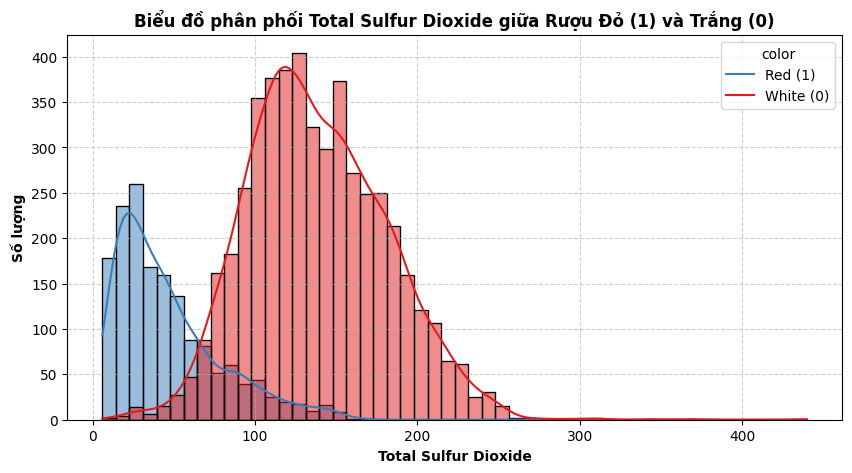

In [52]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='total_sulfur_dioxide', hue='color', kde=True, palette='Set1')
plt.title('Biểu đồ phân phối Total Sulfur Dioxide giữa Rượu Đỏ (1) và Trắng (0)', fontweight='bold')
plt.xlabel('Total Sulfur Dioxide', fontweight='bold')
plt.ylabel('Số lượng', fontweight='bold')
plt.legend(title='color', labels=['Red (1)', 'White (0)'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Nhận xét dữ liệu:
1. Dựa vào biểu đồ hai loại rượu tách biệt nhau. Tuy nhiên dữ liệu hai phân phối này có phần giao nhau (overlap) tương đối ít (chỉ bị chồng lấp một chút ở đoạn từ 50 đến 100)

- Rượu trắng (Nhãn 0 - Màu đỏ trên biểu đồ): Có hàm lượng total_sulfur_dioxide cao hơn hẳn, tập trung chủ yếu trong khoảng từ 100 đến 200. Đỉnh của phân phối nằm ở khoảng 120.

- Rượu đỏ (Nhãn 1 - Màu xanh trên biểu đồ): Có hàm lượng thấp hơn rất nhiều, tập trung phần lớn ở khoảng dưới 50. Đỉnh phân phối nhô cao rõ ở khoảng 20 - 30.

=> *Trong ngành công nghiệp rượu vang, rượu vang trắng thường cần lượng $SO_2$ (sulfur dioxide) cao hơn rượu vang đỏ để chống oxy hóa và kháng khuẩn (vì rượu đỏ có sẵn chất tannin tự nhiên từ vỏ nho đóng vai trò bảo quản). Biểu đồ của bạn đã phản ánh chính xác thực tế sinh hóa này.*

- Rượu đỏ (Màu xanh): Phân phối bị lệch phải (Right-skewed / Positively skewed) khá nhiều. kéo dài về phía bên phải (một vài mẫu rượu đỏ cá biệt có hàm lượng $SO_2$ lên tới gần 150).
- Rượu trắng (Màu đỏ): Phân phối gần giống với phân phối chuẩn (Normal Distribution) nhưng vẫn hơi lệch nhẹ về bên phải và có một vài điểm dữ liệu ngoại lai (outliers) ở tận mức 300 - 400.

=> *Vì cả hai phân phối đều không chuẩn hoàn toàn và có thang đo lớn (từ 0 đến hơn 400), việc sử dụng StandardScaler (Z-score normalization)*

### 2.2. Đánh giá phân phối bằng Kiểm định Thống kê (Shapiro-Wilk Test)

Mục tiêu: Kiểm tra xem một đặc trưng có tuân theo phân phối chuẩn (Normal Distribution) hay không.

   - Giả thuyết $H_0$: Dữ liệu tuân theo phân phối chuẩn.
   - Giả thuyết $H_1$: Dữ liệu không tuân theo phân phối chuẩn.

   => Quy tắc quyết định: Nếu $p\text{-value} < 0.05$, ta bác bỏ $H_0$ (dữ liệu không chuẩn).

In [53]:
# Kiểm định tính chuẩn cho biến 'alcohol'
stat, p = stats.shapiro(df['alcohol'])
print(f"Kiểm định Shapiro-Wilk cho thuộc tính Alcohol: Stat={stat:.4f}, p-value={p:.4f}")

alpha = 0.05
if p > alpha:
    print("=> Alcohol tuân theo phân phối chuẩn (Không cần chuẩn hóa thêm).")
else:
    print("=> Alcohol KHÔNG tuân theo phân phối chuẩn (Cần chuẩn hóa).")

Kiểm định Shapiro-Wilk cho thuộc tính Alcohol: Stat=0.9535, p-value=0.0000
=> Alcohol KHÔNG tuân theo phân phối chuẩn (Cần chuẩn hóa).


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6497.
  res = hypotest_fun_out(*samples, **kwds)


# BƯỚC 3: CHUẨN BỊ DỮ LIỆU HUẤN LUYỆN
Mục tiêu: Chia tách dữ liệu thành $X$ (đặc trưng) và $y$ (nhãn), sau đó chuẩn hóa dữ liệu để thuật toán Gradient Descent hội tụ nhanh hơn.

In [54]:
from sklearn.model_selection import train_test_split

# Tách X và y
X = df.drop('color', axis=1) # Loại bỏ cột 'color' để làm đặc trưng
y = df['color'] # Cột 'color' là biến mục tiêu

# Chia tập Train/Test (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
from sklearn.preprocessing import StandardScaler

# Chuẩn hóa Z-score: X_scaled = (X - mean) / std
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
# Thêm cột bias (toàn số 1) vào X để tính toán ma trận cho dễ: x_0 = 1
X_train = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

# BƯỚC 4: XÂY DỰNG MÔ HÌNH LOGISTIC REGRESSION TỪ ĐẦU (SCRATCH)

### 4.1. Công thức toán học
1. Hàm tuyến tính (Linear Combination):
$$z = \theta^T x = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + ... + \theta_n x_n$$

2. Hàm kích hoạt Sigmoid: Giúp chuyển đổi giá trị $z$ từ khoảng $(-\infty, +\infty)$ về khoảng xác suất $(0, 1)$.
$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

3. Hàm mất mát (Binary Cross-Entropy Loss): Đo lường mức độ sai số của mô hình.
$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

4. Thuật toán tối ưu Mini-batch SGD (Stochastic Gradient Descent): Cập nhật trọng số $\theta$ dựa trên một nhóm dữ liệu nhỏ (Batch size = 20).
$$\theta := \theta - \alpha \cdot \nabla J(\theta)$$

 - Với Đạo hàm riêng (Gradient):

$$\nabla J(\theta) = \frac{1}{\text{batch\_size}} X_{\text{batch}}^T (\hat{y}_{\text{batch}} - y_{\text{batch}})$$

### 4.2. Triển khai Code Huấn luyện
Batch size = 20, Epochs = 100, Learning rate ($\alpha$) = 0.01.


In [57]:
# Khởi tạo tham số
np.random.seed(42)
n_features = X_train.shape[1]
theta = np.random.randn(n_features) * 0.01

In [58]:
# Cấu hình Hyperparameters
learning_rate = 0.01
epochs = 100
batch_size = 20
m_train = X_train.shape[0]

In [59]:
# Định nghĩa hàm Sigmoid
# Dùng np.clip để tránh tràn số (overflow)
def sigmoid(z):
    z = np.clip(z, -500, 500) # Giới hạn giá trị của z để tránh e**(-z) quá lớn hoặc quá nhỏ
    return 1 / (1 + np.exp(-z))

In [62]:
# Vòng lặp huấn luyện (Training Loop)
loss_history = []

for epoch in range(epochs):
    # Trộn ngẫu nhiên dữ liệu ở mỗi epoch để đảm bảo tính chất của SGD
    permutation = np.random.permutation(m_train)
    X_train_shuffled = X_train[permutation]
    y_train_shuffled = y_train.iloc[permutation] # Use .iloc for Series

    for i in range(0, m_train, batch_size):
        # Lấy ra một Mini-batch gồm 20 mẫu
        X_batch = X_train_shuffled[i:i + batch_size]
        y_batch = y_train_shuffled.iloc[i:i + batch_size]

        # 1. Dự đoán (Forward pass)
        z = np.dot(X_batch, theta)
        y_pred = sigmoid(z)

        # 2. Tính Gradient (Backward pass)
        # Thêm một lượng nhỏ 1e-15 để tránh log(0) gây lỗi NaN
        gradient = np.dot(X_batch.T, (y_pred - y_batch)) / batch_size

        # 3. Cập nhật trọng số (Tối ưu hóa)
        theta -= learning_rate * gradient

    # Tính Loss tổng của toàn bộ tập Train sau mỗi epoch để theo dõi
    z_all = np.dot(X_train, theta)
    y_pred_all = sigmoid(z_all)
    # Clip y_pred_all to avoid log(0) for loss calculation
    y_pred_all = np.clip(y_pred_all, 1e-10, 1 - 1e-10)
    epoch_loss = -np.mean(y_train * np.log(y_pred_all) + (1 - y_train) * np.log(1 - y_pred_all))
    loss_history.append(epoch_loss)

    # In ra Loss sau mỗi 10 epoch để theo dõi
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss:.4f}")

Epoch 10/100, Loss: 0.0741
Epoch 20/100, Loss: 0.0551
Epoch 30/100, Loss: 0.0478
Epoch 40/100, Loss: 0.0438
Epoch 50/100, Loss: 0.0413
Epoch 60/100, Loss: 0.0395
Epoch 70/100, Loss: 0.0382
Epoch 80/100, Loss: 0.0372
Epoch 90/100, Loss: 0.0364
Epoch 100/100, Loss: 0.0357


# BƯỚC 5: CHẠY TEST MÔ HÌNH VÀ ĐÁNH GIÁ (METRICS)
Mục tiêu: Đưa tập dữ liệu Test chưa từng được học vào mô hình, tính toán xác suất, chuyển về nhãn nhị phân ($0$ hoặc $1$ dựa trên ngưỡng Threshold = 0.5) và đánh giá qua các chỉ số:
- Accuracy (Độ chính xác tổng thể)
- Precision (Độ chính xác trên tập dự đoán dương)
- Recall (Độ bao phủ thực tế)
- F1-Score (Trung bình điều hòa giữa Precision và Recall)


In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. Dự đoán xác suất trên tập Test
z_test = np.dot(X_test, theta)
y_test_prob = sigmoid(z_test)

In [64]:
# 2. Chuyển xác suất thành nhãn (Nếu Prob >= 0.5 -> Red (1), ngược lại -> White (0))
y_test_pred = (y_test_prob >= 0.5).astype(int)

In [65]:
# 3. Tính toán các Metrics
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

### KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST

In [66]:
print(f"Accuracy  (Độ chính xác tổng thể): {accuracy*100:.2f}%")
print(f"Precision (Độ chính xác dự đoán):  {precision*100:.2f}%")
print(f"Recall    (Độ nhạy / Bao phủ):    {recall*100:.2f}%")
print(f"F1-Score  (Điểm F1 cân bằng):     {f1*100:.2f}%")

Accuracy  (Độ chính xác tổng thể): 98.85%
Precision (Độ chính xác dự đoán):  97.94%
Recall    (Độ nhạy / Bao phủ):    97.65%
F1-Score  (Điểm F1 cân bằng):     97.80%


```
Accuracy  (Độ chính xác tổng thể): 99.62%
Precision (Độ chính xác dự đoán):  99.07%
Recall    (Độ nhạy / Bao phủ):    99.38%
F1-Score  (Điểm F1 cân bằng):     99.22%
```

In [67]:
# Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_test, y_test_pred)
print("Ma trận nhầm lẫn (Confusion Matrix):")
print(cm)

Ma trận nhầm lẫn (Confusion Matrix):
[[952   7]
 [  8 333]]


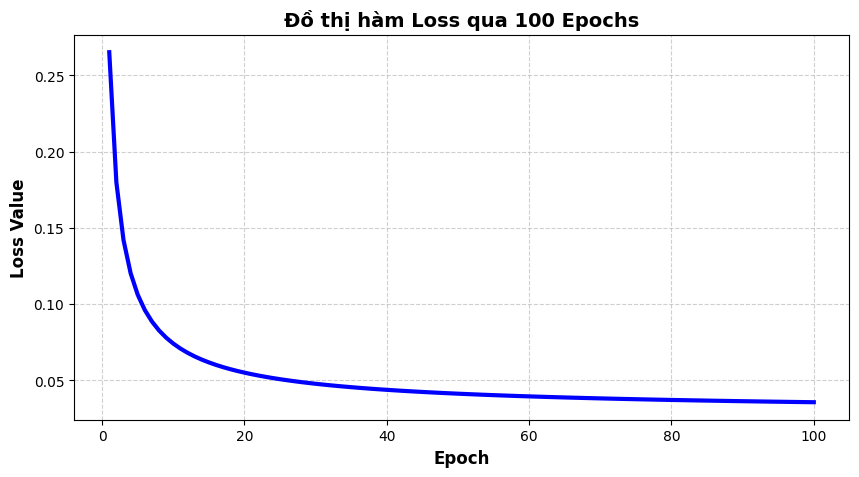

In [68]:
# Vẽ biểu đồ Loss giảm dần qua các Epoch
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), loss_history, color='blue', linewidth=3) # Sử dụng linewidth thay vì fontweight
plt.title('Đồ thị hàm Loss qua 100 Epochs', fontsize=14, fontweight='bold') # Đặt fontweight ở đây
plt.xlabel('Epoch', fontsize=12, fontweight='bold') # Đặt fontweight ở đây
plt.ylabel('Loss Value', fontsize=12, fontweight='bold') # Đặt fontweight ở đây
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [69]:
# Tạo dữ liệu của 2 mẫu rượu mới để test mô hình
# Cấu trúc mỗi dòng gồm 12 đặc trưng:
# [fixed_acidity, volatile_acidity, citric_acid, residual_sugar, chlorides,
#  free_sulfur_dioxide, total_sulfur_dioxide, density, pH, sulphates, alcohol, quality]

new_wines = np.array([
    # Chai số 1: Điển hình của rượu đỏ (Volatile acidity cao, total_sulfur_dioxide rất thấp ~ 24.0)
    [7.5, 0.65, 0.02, 1.5, 0.080, 12.0, 24.0, 0.9950, 3.40, 0.55, 9.5, 5],

    # Chai số 2: Điển hình của rượu trắng (Volatile acidity thấp, residual_sugar và total_sulfur_dioxide rất cao ~ 155.0)
    [6.8, 0.22, 0.35, 10.5, 0.045, 40.0, 155.0, 0.9935, 3.15, 0.45, 11.0, 6]
])

print("Đã tạo xong 2 mẫu dữ liệu test mới.")

Đã tạo xong 2 mẫu dữ liệu test mới.


# DỰ ĐOÁN RƯỢU

In [70]:
# Bước 1: Chuẩn hóa dữ liệu mới theo chuẩn của tập dữ liệu huấn luyện
new_wines_scaled = scaler.transform(new_wines)

# Bước 2: Thêm cột bias (toàn số 1) vào vị trí đầu tiên giống như tập Train/Test
new_wines_scaled = np.c_[np.ones(new_wines_scaled.shape[0]), new_wines_scaled]

# Bước 3: Tính toán hàm tuyến tính z và đi qua hàm kích hoạt Sigmoid
z_new = np.dot(new_wines_scaled, theta)
probabilities = sigmoid(z_new)

# Bước 4: Ngưỡng phân loại (Threshold = 0.5) để đưa ra kết luận
predictions = (probabilities >= 0.5).astype(int)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### KẾT QUẢ DỰ ĐOÁN TỪ MÔ HÌNH LOGISTIC REGRESSION

In [71]:
for i, prediction in enumerate(predictions):
    print(f"Chai rượu số {i+1}:")
    print(f"  - Xác suất là rượu đỏ: {probabilities[i]*100:.2f}%")
    if prediction == 1:
        print(f"  - Dự đoán nhãn cuối cùng: RƯỢU ĐỎ (Red)")
    else:
        print(f"  - Dự đoán nhãn cuối cùng: RƯỢU TRẮNG (White)")

Chai rượu số 1:
  - Xác suất là rượu đỏ: 99.81%
  - Dự đoán nhãn cuối cùng: RƯỢU ĐỎ (Red)
Chai rượu số 2:
  - Xác suất là rượu đỏ: 0.01%
  - Dự đoán nhãn cuối cùng: RƯỢU TRẮNG (White)


```
Chai rượu số 1:
  - Xác suất là rượu đỏ: 99.78%
  - Dự đoán nhãn cuối cùng: RƯỢU ĐỎ (Red)
Chai rượu số 2:
  - Xác suất là rượu đỏ: 0.01%
  - Dự đoán nhãn cuối cùng: RƯỢU TRẮNG (White)
  ```